# Planetary-Embedded Multi-Agent Systems (PEMAS)

**A Synthetic Experimental Framework for Ecologically Adaptive AI Governance**

**Author:** Sabrina Palis  
**Version:** v0.1  
**Status:** Publication-ready exploratory research notebook  
**Intended archive:** Zenodo  
**Repository:** https://github.com/MinervaRose/pemas-framework

---

## Abstract

Modern AI systems are often designed as if computation were abstract and materially detached. In practice, AI systems depend on energy, cooling, water, hardware, minerals, infrastructure, and finite planetary resources. This notebook introduces **Planetary-Embedded Multi-Agent Systems (PEMAS)**, a synthetic experimental framework in which ecological and planetary variables function as first-class governance signals inside a modular multi-agent architecture.

The framework compares a conventional baseline multi-agent pipeline with a governed PEMAS pipeline. Both systems use the same synthetic tasks and simulated agent components. The key difference is that PEMAS uses a synthetic planetary-state engine and governance layer to regulate recursion, token budgets, model routing, compression, and sufficiency-based stopping.

This notebook does not estimate real-world AI environmental impact. Its purpose is to test whether ecological constraints can be operationalized as internal governance variables in an agentic AI system.

# 1. Research Context

## 1.1 Motivation

AI systems are frequently discussed as if intelligence were separable from the material systems that support it. Yet computation is not substrate-free. Inference and training depend on electrical grids, cooling systems, hardware supply chains, water, minerals, and physical infrastructure.

This project explores a different design assumption:

> AI architectures can be designed to understand themselves as participants inside a finite planetary system.

The goal is not to moralize computation, nor to claim that a small simulation can capture real planetary impact. The goal is to investigate whether ecological constraints can be made operational inside an AI architecture.

## 1.2 Research Question

**Primary question**

> Can a multi-agent AI system maintain useful task performance while dynamically adapting cognition to simulated planetary constraints?

**Secondary questions**

- Can ecological governance reduce unnecessary recursive reasoning?
- Does adaptive sufficiency reduce computational waste?
- How does ecological constraint alter model-routing behavior?
- Can planetary-aware governance reduce runaway multi-agent loops?
- What computational behaviors emerge under ecological boundedness?

## 1.3 Contribution

This notebook contributes a self-contained synthetic framework for studying ecological governance in multi-agent AI systems. It includes:

1. a synthetic planetary-state engine,
2. a conventional baseline multi-agent pipeline,
3. a governed PEMAS pipeline,
4. comparative experiments across ecological scenarios,
5. interpretable metrics and visualizations,
6. a discussion of limitations and future extensions.

The contribution is architectural and exploratory, not a claim of real-world environmental measurement.

# 2. Methodological Positioning

PEMAS is not primarily a carbon accounting tool, a climate model, or a production AI sustainability system.

Instead, it sits at the intersection of:

- AI governance,
- sustainable computing,
- multi-agent systems,
- bounded rationality,
- cybernetic feedback,
- ecological systems thinking,
- resource-aware orchestration.

The experiment is intentionally synthetic. This allows the architecture to remain transparent, reproducible, and inspectable.

The central methodological claim is:

> A synthetic ecological state can be represented as a governance signal that changes agentic computation in measurable ways.

# 3. Environment Setup

In [1]:
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple
from pathlib import Path
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducible output folders
PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
LOG_DIR = OUTPUT_DIR / "logs"

for folder in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Output directory: {OUTPUT_DIR.resolve()}")

Output directory: /content/outputs


# 4. Planetary-State Simulation

## 4.1 Design Principle

The planetary-state engine provides the ecological operating context for PEMAS.

It is synthetic and does not estimate real AI environmental impact. Its purpose is to provide structured governance signals.

All variables are normalized between `0.0` and `1.0`:

| Variable | Meaning |
|---|---|
| `carbon_intensity` | Simulated grid carbon burden |
| `water_stress` | Simulated cooling-water stress |
| `thermal_load` | Simulated infrastructure heat stress |
| `energy_availability` | Simulated energy abundance or scarcity |
| `hardware_scarcity` | Simulated compute infrastructure constraint |
| `ecological_load_index` | Composite ecological pressure signal |

In [2]:
@dataclass(frozen=True)
class PlanetaryState:
    """Synthetic ecological operating context for PEMAS experiments."""

    timestep: int
    carbon_intensity: float
    water_stress: float
    thermal_load: float
    energy_availability: float
    hardware_scarcity: float
    ecological_load_index: float

    def to_dict(self) -> Dict[str, float]:
        return asdict(self)


def compute_ecological_load_index(
    carbon_intensity: float,
    water_stress: float,
    thermal_load: float,
    energy_availability: float,
    hardware_scarcity: float,
) -> float:
    """Compute a simple synthetic ecological load index.

    The index rises with carbon intensity, water stress, thermal load,
    hardware scarcity, and low energy availability.
    """

    values = [
        carbon_intensity,
        water_stress,
        thermal_load,
        hardware_scarcity,
        1 - energy_availability,
    ]
    return float(np.clip(np.mean(values), 0.0, 1.0))

## 4.2 Synthetic Scenario Definitions

The framework uses six scenario types. These are controlled experimental environments, not empirical environmental measurements.

In [3]:
SCENARIO_RANGES: Dict[str, Dict[str, Tuple[float, float]]] = {
    "low_stress": {
        "carbon_intensity": (0.05, 0.25),
        "water_stress": (0.05, 0.25),
        "thermal_load": (0.05, 0.25),
        "energy_availability": (0.75, 0.95),
        "hardware_scarcity": (0.05, 0.25),
    },
    "moderate_stress": {
        "carbon_intensity": (0.35, 0.60),
        "water_stress": (0.30, 0.60),
        "thermal_load": (0.30, 0.60),
        "energy_availability": (0.40, 0.70),
        "hardware_scarcity": (0.30, 0.60),
    },
    "high_stress": {
        "carbon_intensity": (0.70, 0.95),
        "water_stress": (0.70, 0.95),
        "thermal_load": (0.70, 0.95),
        "energy_availability": (0.05, 0.30),
        "hardware_scarcity": (0.70, 0.95),
    },
    "drought": {
        "carbon_intensity": (0.45, 0.75),
        "water_stress": (0.85, 1.00),
        "thermal_load": (0.65, 0.95),
        "energy_availability": (0.30, 0.60),
        "hardware_scarcity": (0.30, 0.60),
    },
    "energy_scarcity": {
        "carbon_intensity": (0.60, 0.90),
        "water_stress": (0.35, 0.65),
        "thermal_load": (0.45, 0.75),
        "energy_availability": (0.05, 0.25),
        "hardware_scarcity": (0.40, 0.70),
    },
    "hardware_scarcity": {
        "carbon_intensity": (0.35, 0.65),
        "water_stress": (0.30, 0.55),
        "thermal_load": (0.35, 0.65),
        "energy_availability": (0.45, 0.75),
        "hardware_scarcity": (0.85, 1.00),
    },
}


def generate_planetary_state(
    scenario: str,
    timestep: int = 0,
    seed: Optional[int] = None,
) -> PlanetaryState:
    if scenario not in SCENARIO_RANGES:
        valid = ", ".join(SCENARIO_RANGES.keys())
        raise ValueError(f"Unknown scenario: {scenario}. Valid scenarios: {valid}")

    rng = random.Random(seed)
    ranges = SCENARIO_RANGES[scenario]

    values = {
        variable: rng.uniform(low, high)
        for variable, (low, high) in ranges.items()
    }

    ecological_load_index = compute_ecological_load_index(**values)

    return PlanetaryState(
        timestep=timestep,
        ecological_load_index=ecological_load_index,
        **values,
    )


def planetary_states_to_dataframe(states: List[PlanetaryState]) -> pd.DataFrame:
    return pd.DataFrame([state.to_dict() for state in states])


example_state = generate_planetary_state("moderate_stress", seed=42)
pd.DataFrame([example_state.to_dict()])

,timestep,carbon_intensity,water_stress,thermal_load,energy_availability,hardware_scarcity,ecological_load_index
0,0,0.509857,0.307503,0.382509,0.466963,0.520941,0.450769


## 4.3 Dynamic Stress Trajectory

Dynamic trajectories allow ecological operating conditions to change over time. This matters because a planetary-embedded system should be able to adapt its behavior as constraints shift.

In [4]:
def interpolate_ranges(
    start_range: Tuple[float, float],
    end_range: Tuple[float, float],
    alpha: float,
) -> Tuple[float, float]:
    start_low, start_high = start_range
    end_low, end_high = end_range
    return (
        start_low + alpha * (end_low - start_low),
        start_high + alpha * (end_high - start_high),
    )


def generate_transition_trajectory(
    start_scenario: str,
    end_scenario: str,
    timesteps: int = 20,
    seed: Optional[int] = None,
) -> List[PlanetaryState]:
    if timesteps < 2:
        raise ValueError("timesteps must be at least 2.")

    rng = random.Random(seed)
    trajectory = []

    for timestep in range(timesteps):
        alpha = timestep / (timesteps - 1)
        values = {}

        for variable in SCENARIO_RANGES[start_scenario].keys():
            interpolated_range = interpolate_ranges(
                SCENARIO_RANGES[start_scenario][variable],
                SCENARIO_RANGES[end_scenario][variable],
                alpha,
            )
            values[variable] = rng.uniform(*interpolated_range)

        ecological_load_index = compute_ecological_load_index(**values)

        trajectory.append(
            PlanetaryState(
                timestep=timestep,
                ecological_load_index=ecological_load_index,
                **values,
            )
        )

    return trajectory


trajectory = generate_transition_trajectory(
    start_scenario="low_stress",
    end_scenario="high_stress",
    timesteps=20,
    seed=7,
)

trajectory_df = planetary_states_to_dataframe(trajectory)
trajectory_df.head()

,timestep,carbon_intensity,water_stress,thermal_load,energy_availability,hardware_scarcity,ecological_load_index
0,0,0.114767,0.080170,0.180187,0.764487,0.157176,0.153562
1,1,0.158311,0.095963,0.187033,0.720756,0.172081,0.178526
2,2,0.132760,0.137041,0.205559,0.846038,0.143833,0.154631
3,3,0.199042,0.283072,0.349655,0.759450,0.235099,0.261484
4,4,0.392369,0.196649,0.367572,0.663602,0.217212,0.302040


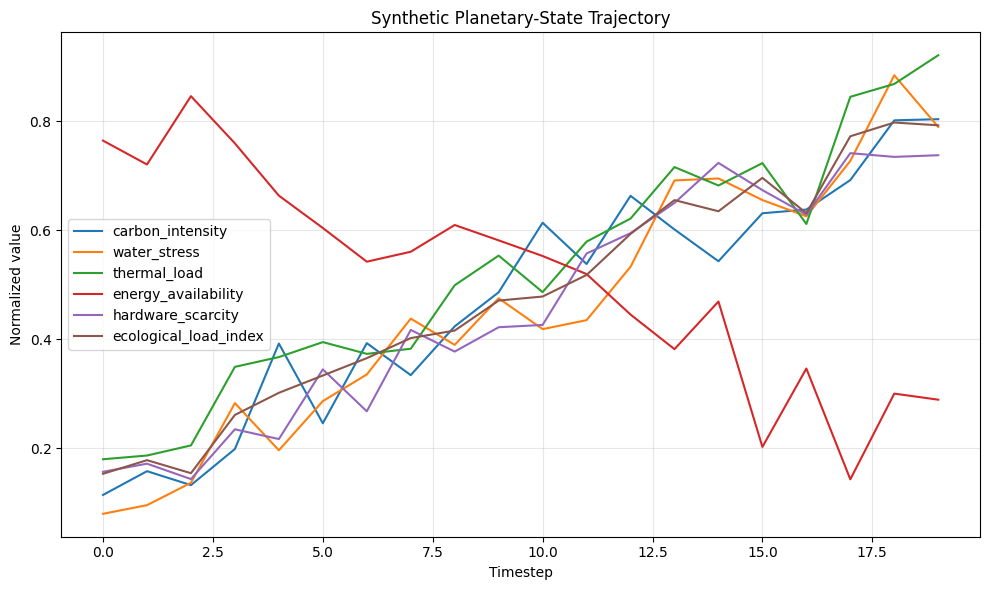

In [5]:
variables_to_plot = [
    "carbon_intensity",
    "water_stress",
    "thermal_load",
    "energy_availability",
    "hardware_scarcity",
    "ecological_load_index",
]

fig, ax = plt.subplots(figsize=(10, 6))

for variable in variables_to_plot:
    ax.plot(trajectory_df["timestep"], trajectory_df[variable], label=variable)

ax.set_xlabel("Timestep")
ax.set_ylabel("Normalized value")
ax.set_title("Synthetic Planetary-State Trajectory")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_planetary_state_trajectory.png", dpi=300)
plt.show()

### Interpretation

The synthetic trajectory demonstrates how ecological operating conditions evolve over time inside the PEMAS framework. Carbon intensity, water stress, thermal load, and hardware scarcity progressively increase, while energy availability decreases.

This matters because PEMAS does not treat ecological context as passive metadata. The planetary-state vector becomes an active governance signal capable of modifying computational behavior.

The trajectory therefore establishes the central architectural principle of the framework:

> ecological state influences cognition.

Importantly, the trajectory is intentionally synthetic. The objective is not environmental realism, but the creation of controlled operating conditions under which governance adaptation can be observed reproducibly.

## 4.4 Scenario Profile Summary

Before using scenarios in experiments, we verify that they generate distinct operating contexts.

In [6]:
scenario_rows = []

for scenario_name in SCENARIO_RANGES:
    samples = [
        generate_planetary_state(scenario_name, seed=i).to_dict()
        for i in range(50)
    ]
    sample_df = pd.DataFrame(samples)
    means = sample_df.mean(numeric_only=True).to_dict()
    means["scenario"] = scenario_name
    scenario_rows.append(means)

scenario_summary = pd.DataFrame(scenario_rows)
scenario_summary = scenario_summary[["scenario"] + variables_to_plot]
scenario_summary.to_csv(TABLE_DIR / "scenario_profile_summary.csv", index=False)

scenario_summary

,scenario,carbon_intensity,water_stress,thermal_load,energy_availability,hardware_scarcity,ecological_load_index
0,low_stress,0.144799,0.155402,0.152717,0.848045,0.141220,0.149218
1,moderate_stress,0.468499,0.458103,0.454076,0.547068,0.436829,0.454088
2,high_stress,0.818499,0.831752,0.828397,0.172557,0.814025,0.824023
3,drought,0.592198,0.929051,0.804076,0.447068,0.436829,0.663017
4,energy_scarcity,0.742198,0.508103,0.604076,0.148045,0.536829,0.648632
5,hardware_scarcity,0.492198,0.431752,0.504076,0.597068,0.918415,0.549875


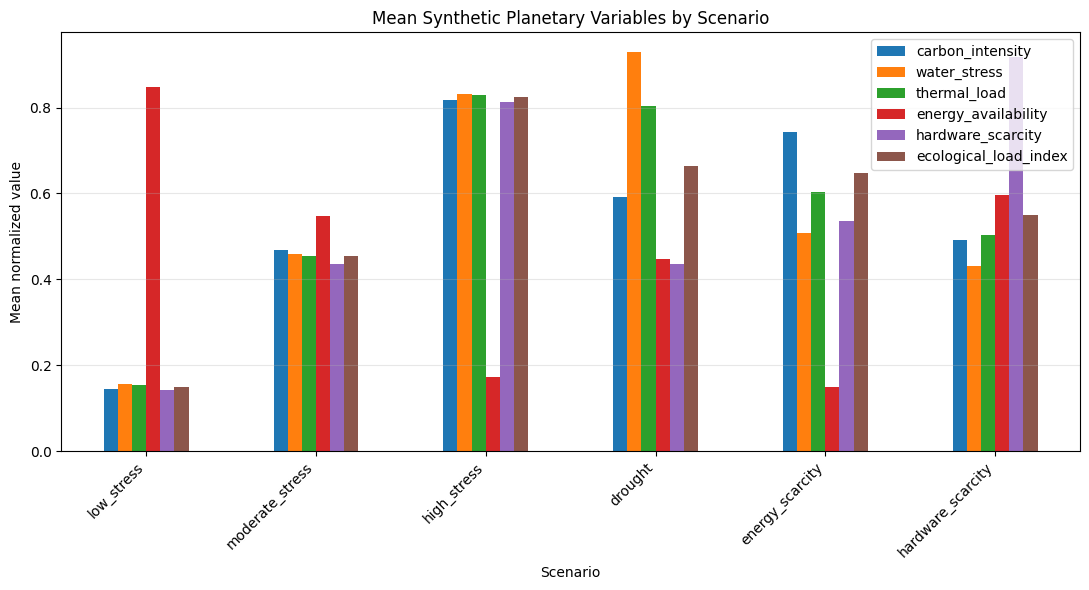

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

scenario_summary.set_index("scenario")[variables_to_plot].plot(kind="bar", ax=ax)

ax.set_ylabel("Mean normalized value")
ax.set_xlabel("Scenario")
ax.set_title("Mean Synthetic Planetary Variables by Scenario")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_scenario_profile_summary.png", dpi=300)
plt.show()

### Interpretation

The scenario profiles create controlled ecological contrast conditions for the experiment.

Low-stress conditions represent relatively permissive computational environments, while high-stress conditions simulate constrained operating regimes. Intermediate scenarios such as drought, energy scarcity, and hardware scarcity introduce more specific ecological pressures.

The goal is not to reproduce real environmental states. Instead, the scenarios provide structured governance environments that allow the same agentic pipeline to be tested under changing planetary conditions.

This distinction is methodologically important because PEMAS is an architectural experiment rather than an environmental prediction system.

# 5. Task Set

The experiment uses a small synthetic task set. The purpose is not to benchmark general intelligence. The purpose is to test whether governance logic changes agentic computational behavior under different ecological contexts.

Each task has:

- a task type,
- a prompt,
- a difficulty score,
- an ambiguity score.

In [8]:
@dataclass(frozen=True)
class Task:
    task_id: str
    task_type: str
    prompt: str
    difficulty: float
    ambiguity: float

    def to_dict(self) -> Dict[str, object]:
        return asdict(self)


TASKS = [
    Task(
        task_id="T001",
        task_type="summarization",
        prompt="Summarize a short technical abstract about ecological AI governance.",
        difficulty=0.30,
        ambiguity=0.20,
    ),
    Task(
        task_id="T002",
        task_type="classification",
        prompt="Classify whether a system behavior represents escalation, throttling, or stopping.",
        difficulty=0.40,
        ambiguity=0.25,
    ),
    Task(
        task_id="T003",
        task_type="structured_reasoning",
        prompt="Explain why recursive agent loops may increase computational waste.",
        difficulty=0.55,
        ambiguity=0.35,
    ),
    Task(
        task_id="T004",
        task_type="planning",
        prompt="Design a lightweight governance rule for model routing under constraint.",
        difficulty=0.65,
        ambiguity=0.45,
    ),
    Task(
        task_id="T005",
        task_type="scientific_reasoning",
        prompt="Discuss limitations of using synthetic ecological variables in AI experiments.",
        difficulty=0.75,
        ambiguity=0.55,
    ),
    Task(
        task_id="T006",
        task_type="synthesis",
        prompt="Synthesize a short argument connecting bounded rationality and ecological governance.",
        difficulty=0.85,
        ambiguity=0.65,
    ),
]

tasks_df = pd.DataFrame([task.to_dict() for task in TASKS])
tasks_df.to_csv(TABLE_DIR / "synthetic_task_set.csv", index=False)

tasks_df

,task_id,task_type,prompt,difficulty,ambiguity
0,T001,summarization,Summarize a short technical abstract about eco...,0.30,0.20
1,T002,classification,Classify whether a system behavior represents ...,0.40,0.25
2,T003,structured_reasoning,Explain why recursive agent loops may increase...,0.55,0.35
3,T004,planning,Design a lightweight governance rule for model...,0.65,0.45
4,T005,scientific_reasoning,Discuss limitations of using synthetic ecologi...,0.75,0.55
5,T006,synthesis,Synthesize a short argument connecting bounded...,0.85,0.65


# 6. Baseline Multi-Agent Pipeline

## 6.1 Baseline Design

The baseline represents a conventional simulated multi-agent workflow:

```text
Task → Planner → Worker → Critic → Refinement Loop → Final Output
```

It does not observe ecological state. It refines according to quality threshold, critic recommendation, and maximum iteration count.

In [9]:
@dataclass
class BaselineState:
    task_id: str
    task_type: str
    max_iterations: int
    target_quality: float
    cumulative_tokens: int = 0
    quality_history: List[float] = field(default_factory=list)
    uncertainty_history: List[float] = field(default_factory=list)
    token_history: List[int] = field(default_factory=list)
    outputs: List[Dict[str, object]] = field(default_factory=list)
    critic_logs: List[Dict[str, object]] = field(default_factory=list)
    stopping_reason: Optional[str] = None

    def to_summary(self) -> Dict[str, object]:
        return {
            "system": "baseline",
            "task_id": self.task_id,
            "task_type": self.task_type,
            "scenario": "none",
            "iterations_completed": len(self.quality_history),
            "cumulative_tokens": self.cumulative_tokens,
            "cumulative_ecological_cost_proxy": np.nan,
            "final_quality": self.quality_history[-1] if self.quality_history else np.nan,
            "final_uncertainty": self.uncertainty_history[-1] if self.uncertainty_history else np.nan,
            "mean_ecological_load": np.nan,
            "stopping_reason": self.stopping_reason,
        }


class PlannerAgent:
    def plan(self, task: Task, force_compression: bool = False) -> Dict[str, object]:
        estimated_complexity = float(np.clip(
            0.65 * task.difficulty + 0.35 * task.ambiguity,
            0.0,
            1.0,
        ))

        recommended_depth = int(np.ceil(1 + estimated_complexity * 4))

        if force_compression:
            recommended_depth = min(recommended_depth, 2)
            steps = ["interpret task", "produce concise answer", "stop"]
        else:
            steps = ["interpret task", "produce draft response", "evaluate quality", "refine if needed"]

        return {
            "task_id": task.task_id,
            "task_type": task.task_type,
            "estimated_complexity": estimated_complexity,
            "recommended_depth": recommended_depth,
            "force_compression": force_compression,
            "steps": steps,
        }

    def compress_plan(self, plan: Dict[str, object]) -> Dict[str, object]:
        compressed = dict(plan)
        compressed["recommended_depth"] = min(plan["recommended_depth"], 2)
        compressed["force_compression"] = True
        compressed["steps"] = ["retain core answer", "compress reasoning", "finalize"]
        return compressed


class BaselineWorkerAgent:
    def __init__(self, seed: int = 0):
        self.rng = random.Random(seed)

    def execute(self, task: Task, plan: Dict[str, object], iteration: int) -> Dict[str, object]:
        complexity = plan["estimated_complexity"]
        base_tokens = 300 + int(900 * complexity)
        iteration_tokens = int(120 * iteration)
        noise = self.rng.randint(-60, 80)
        tokens_used = max(150, base_tokens + iteration_tokens + noise)

        improvement = 0.12 * iteration
        base_quality = 0.42 + improvement + 0.22 * (1 - task.difficulty)
        ambiguity_penalty = 0.14 * task.ambiguity
        quality_signal = base_quality - ambiguity_penalty + self.rng.uniform(-0.04, 0.04)
        simulated_quality = float(np.clip(quality_signal, 0.0, 1.0))

        return {
            "task_id": task.task_id,
            "iteration": iteration,
            "tokens_used": tokens_used,
            "simulated_quality_signal": simulated_quality,
            "model_used": "baseline_default_model",
            "force_compression": False,
            "completed": True,
        }


class CriticAgent:
    def __init__(self, seed: int = 1):
        self.rng = random.Random(seed)

    def evaluate(self, task: Task, worker_output: Dict[str, object]) -> Dict[str, object]:
        quality_score = float(np.clip(
            worker_output["simulated_quality_signal"] + self.rng.uniform(-0.03, 0.03),
            0.0,
            1.0,
        ))

        uncertainty_score = float(np.clip(
            0.20 + 0.45 * task.ambiguity + 0.25 * task.difficulty - 0.35 * quality_score,
            0.0,
            1.0,
        ))

        recommend_refinement = quality_score < 0.82 and uncertainty_score > 0.18

        return {
            "task_id": task.task_id,
            "iteration": worker_output["iteration"],
            "quality_score": quality_score,
            "uncertainty_score": uncertainty_score,
            "recommend_refinement": recommend_refinement,
        }


def run_baseline(
    task: Task,
    max_iterations: int = 5,
    target_quality: float = 0.82,
    seed: int = 0,
) -> BaselineState:
    planner = PlannerAgent()
    worker = BaselineWorkerAgent(seed=seed)
    critic = CriticAgent(seed=seed + 1)

    plan = planner.plan(task)

    state = BaselineState(
        task_id=task.task_id,
        task_type=task.task_type,
        max_iterations=max_iterations,
        target_quality=target_quality,
    )

    for iteration in range(max_iterations):
        worker_output = worker.execute(task, plan, iteration)
        critic_output = critic.evaluate(task, worker_output)

        state.outputs.append(worker_output)
        state.critic_logs.append(critic_output)
        state.quality_history.append(critic_output["quality_score"])
        state.uncertainty_history.append(critic_output["uncertainty_score"])
        state.token_history.append(worker_output["tokens_used"])
        state.cumulative_tokens += worker_output["tokens_used"]

        if critic_output["quality_score"] >= target_quality:
            state.stopping_reason = "target_quality_reached"
            break

        if not critic_output["recommend_refinement"]:
            state.stopping_reason = "critic_stopped_refinement"
            break

    if state.stopping_reason is None:
        state.stopping_reason = "max_iterations_reached"

    return state

## 6.2 Baseline Execution

In [10]:
baseline_states = [
    run_baseline(task, max_iterations=5, target_quality=0.82, seed=100 + i)
    for i, task in enumerate(TASKS)
]

baseline_summary = pd.DataFrame([state.to_summary() for state in baseline_states])
baseline_summary.to_csv(TABLE_DIR / "baseline_summary.csv", index=False)

baseline_summary

,system,task_id,task_type,scenario,iterations_completed,cumulative_tokens,cumulative_ecological_cost_proxy,final_quality,final_uncertainty,mean_ecological_load,stopping_reason
0,baseline,T001,summarization,none,1,515,NaN,0.547631,0.173329,NaN,critic_stopped_refinement
1,baseline,T002,classification,none,2,1411,NaN,0.677876,0.175243,NaN,critic_stopped_refinement
2,baseline,T003,structured_reasoning,none,4,3691,NaN,0.849393,0.197712,NaN,target_quality_reached
3,baseline,T004,planning,none,5,5360,NaN,0.902967,0.248961,NaN,target_quality_reached
4,baseline,T005,scientific_reasoning,none,5,5554,NaN,0.898366,0.320572,NaN,target_quality_reached
5,baseline,T006,synthesis,none,5,6279,NaN,0.834512,0.412921,NaN,target_quality_reached


### Interpretation

The baseline system functions as the experimental control condition.

Its behavior is governed primarily by task-quality thresholds and refinement logic. Because it does not observe ecological state, recursive refinement continues whenever uncertainty remains sufficiently high.

This reflects a common assumption in contemporary AI systems:

> additional computation is implicitly treated as permissible unless explicit technical limits are reached.

The baseline therefore provides a useful comparison point for evaluating whether ecological governance changes computational behavior in PEMAS.

# 7. PEMAS Governed Pipeline

## 7.1 PEMAS Design

The PEMAS system inserts ecological governance into the reasoning loop.

```text
Task
  ↓
Planetary State
  ↓
Planetary Governor
  ↓
Planner
  ↓
Worker
  ↓
Critic
  ↓
Sufficiency Agent
  ↓
Continue / Compress / Reroute / Stop
```

The key difference from the baseline is that ecological state can alter computational behavior.

In [11]:
@dataclass
class PEMASState:
    task_id: str
    task_type: str
    scenario: str
    max_iterations: int
    target_quality: float
    cumulative_tokens: int = 0
    cumulative_ecological_cost_proxy: float = 0.0
    quality_history: List[float] = field(default_factory=list)
    uncertainty_history: List[float] = field(default_factory=list)
    token_history: List[int] = field(default_factory=list)
    planetary_history: List[Dict[str, float]] = field(default_factory=list)
    governor_history: List[Dict[str, object]] = field(default_factory=list)
    sufficiency_history: List[Dict[str, object]] = field(default_factory=list)
    outputs: List[Dict[str, object]] = field(default_factory=list)
    critic_logs: List[Dict[str, object]] = field(default_factory=list)
    stopping_reason: Optional[str] = None

    def to_summary(self) -> Dict[str, object]:
        return {
            "system": "PEMAS",
            "task_id": self.task_id,
            "task_type": self.task_type,
            "scenario": self.scenario,
            "iterations_completed": len(self.quality_history),
            "cumulative_tokens": self.cumulative_tokens,
            "cumulative_ecological_cost_proxy": self.cumulative_ecological_cost_proxy,
            "final_quality": self.quality_history[-1] if self.quality_history else np.nan,
            "final_uncertainty": self.uncertainty_history[-1] if self.uncertainty_history else np.nan,
            "mean_ecological_load": np.mean([p["ecological_load_index"] for p in self.planetary_history]) if self.planetary_history else np.nan,
            "stopping_reason": self.stopping_reason,
        }


class PEMASWorkerAgent:
    def __init__(self, seed: int = 0):
        self.rng = random.Random(seed)

    def execute(
        self,
        task: Task,
        plan: Dict[str, object],
        iteration: int,
        max_tokens: int,
        model_route: str,
    ) -> Dict[str, object]:
        complexity = plan["estimated_complexity"]
        force_compression = plan.get("force_compression", False)

        model_multiplier = {
            "large_allowed": 1.15,
            "small_preferred": 0.90,
            "small_only": 0.70,
        }.get(model_route, 0.85)

        base_tokens = 300 + int(850 * complexity * model_multiplier)
        iteration_tokens = int(90 * iteration)
        compression_discount = 0.65 if force_compression else 1.00
        noise = self.rng.randint(-50, 70)

        tokens_used = int(max(120, (base_tokens + iteration_tokens + noise) * compression_discount))
        tokens_used = min(tokens_used, max_tokens)

        route_quality_bonus = {
            "large_allowed": 0.05,
            "small_preferred": 0.00,
            "small_only": -0.04,
        }.get(model_route, 0.0)

        compression_penalty = -0.03 if force_compression else 0.0
        improvement = 0.10 * iteration

        quality_signal = (
            0.42
            + improvement
            + 0.22 * (1 - task.difficulty)
            - 0.14 * task.ambiguity
            + route_quality_bonus
            + compression_penalty
            + self.rng.uniform(-0.04, 0.04)
        )

        return {
            "task_id": task.task_id,
            "iteration": iteration,
            "tokens_used": tokens_used,
            "simulated_quality_signal": float(np.clip(quality_signal, 0.0, 1.0)),
            "model_used": model_route,
            "force_compression": force_compression,
            "completed": True,
        }


class PlanetaryGovernorAgent:
    def evaluate(
        self,
        planetary_state: PlanetaryState,
        task: Task,
        current_iteration: int,
        cumulative_tokens: int,
    ) -> Dict[str, object]:
        ecological_load = planetary_state.ecological_load_index
        task_pressure = 0.5 * task.difficulty + 0.5 * task.ambiguity

        if ecological_load < 0.35:
            decision = {
                "mode": "low_constraint",
                "allow_recursion": True,
                "model_route": "large_allowed",
                "max_tokens": 1500,
                "allow_escalation": True,
                "force_compression": False,
                "intervention": "Low ecological load: richer reasoning permitted.",
            }
        elif ecological_load < 0.65:
            decision = {
                "mode": "moderate_constraint",
                "allow_recursion": True,
                "model_route": "small_preferred",
                "max_tokens": 900,
                "allow_escalation": task_pressure > 0.70,
                "force_compression": False,
                "intervention": "Moderate ecological load: small route preferred and budget reduced.",
            }
        else:
            decision = {
                "mode": "high_constraint",
                "allow_recursion": current_iteration == 0,
                "model_route": "small_only",
                "max_tokens": 500,
                "allow_escalation": False,
                "force_compression": True,
                "intervention": "High ecological load: recursion restricted and compression required.",
            }

        if cumulative_tokens > 2500 and ecological_load > 0.50:
            decision["allow_recursion"] = False
            decision["force_compression"] = True
            decision["intervention"] += " Cumulative token budget exceeded under stress."

        return decision


class SufficiencyAgent:
    def evaluate(
        self,
        critic_output: Dict[str, object],
        planetary_state: PlanetaryState,
        quality_history: List[float],
        governor_decision: Dict[str, object],
    ) -> Dict[str, object]:
        quality = critic_output["quality_score"]
        uncertainty = critic_output["uncertainty_score"]
        ecological_load = planetary_state.ecological_load_index

        marginal_gain = quality_history[-1] - quality_history[-2] if len(quality_history) >= 2 else quality

        if ecological_load > 0.70:
            quality_threshold = 0.68
            marginal_gain_threshold = 0.06
        elif ecological_load > 0.45:
            quality_threshold = 0.74
            marginal_gain_threshold = 0.04
        else:
            quality_threshold = 0.82
            marginal_gain_threshold = 0.025

        sufficient = False
        reason = "Additional refinement remains permitted."

        if quality >= quality_threshold and uncertainty < 0.40:
            sufficient = True
            reason = "Quality sufficient under current ecological constraints."
        elif len(quality_history) >= 2 and marginal_gain < marginal_gain_threshold and ecological_load > 0.45:
            sufficient = True
            reason = "Marginal improvement too small under ecological stress."
        elif not governor_decision["allow_recursion"] and len(quality_history) > 0:
            sufficient = True
            reason = "Governor restricted further recursion."

        return {
            "sufficient": sufficient,
            "quality_threshold": quality_threshold,
            "marginal_gain": float(marginal_gain),
            "marginal_gain_threshold": marginal_gain_threshold,
            "reason": reason,
        }


def ecological_cost_proxy(tokens_used: int, ecological_load_index: float) -> float:
    return float(tokens_used * (1 + ecological_load_index))


def run_pemas(
    task: Task,
    scenario: str,
    max_iterations: int = 5,
    target_quality: float = 0.82,
    seed: int = 0,
) -> PEMASState:
    planner = PlannerAgent()
    worker = PEMASWorkerAgent(seed=seed)
    critic = CriticAgent(seed=seed + 1)
    governor = PlanetaryGovernorAgent()
    sufficiency = SufficiencyAgent()

    state = PEMASState(
        task_id=task.task_id,
        task_type=task.task_type,
        scenario=scenario,
        max_iterations=max_iterations,
        target_quality=target_quality,
    )

    plan = None

    for iteration in range(max_iterations):
        planetary_state = generate_planetary_state(scenario, timestep=iteration, seed=seed + iteration)
        governor_decision = governor.evaluate(planetary_state, task, iteration, state.cumulative_tokens)

        if plan is None:
            plan = planner.plan(task, force_compression=governor_decision["force_compression"])
        elif governor_decision["force_compression"]:
            plan = planner.compress_plan(plan)

        if not governor_decision["allow_recursion"] and iteration > 0:
            state.planetary_history.append(planetary_state.to_dict())
            state.governor_history.append(governor_decision)
            state.stopping_reason = "governor_stopped_recursion"
            break

        worker_output = worker.execute(
            task=task,
            plan=plan,
            iteration=iteration,
            max_tokens=governor_decision["max_tokens"],
            model_route=governor_decision["model_route"],
        )

        critic_output = critic.evaluate(task, worker_output)

        state.outputs.append(worker_output)
        state.critic_logs.append(critic_output)
        state.quality_history.append(critic_output["quality_score"])
        state.uncertainty_history.append(critic_output["uncertainty_score"])
        state.token_history.append(worker_output["tokens_used"])
        state.cumulative_tokens += worker_output["tokens_used"]

        state.cumulative_ecological_cost_proxy += ecological_cost_proxy(
            worker_output["tokens_used"],
            planetary_state.ecological_load_index,
        )

        state.planetary_history.append(planetary_state.to_dict())
        state.governor_history.append(governor_decision)

        sufficiency_decision = sufficiency.evaluate(
            critic_output,
            planetary_state,
            state.quality_history,
            governor_decision,
        )
        state.sufficiency_history.append(sufficiency_decision)

        if sufficiency_decision["sufficient"]:
            state.stopping_reason = "sufficiency_stop"
            break

        if critic_output["quality_score"] >= target_quality and planetary_state.ecological_load_index < 0.45:
            state.stopping_reason = "target_quality_reached"
            break

    if state.stopping_reason is None:
        state.stopping_reason = "max_iterations_reached"

    return state

# 8. Experimental Design

The PEMAS experiment compares two different architectural assumptions about computation.

The baseline system represents a conventional multi-agent workflow in which recursive reasoning proceeds according to task-quality logic alone. Computation is implicitly treated as available unless explicit technical stopping conditions are reached.

The PEMAS system introduces a different assumption:

> ecological operating conditions can function as endogenous governance signals inside the cognition loop.

Both systems use the same synthetic task set, agent structure, and evaluation logic. The key experimental difference is whether ecological state is permitted to alter computational behavior.

The purpose of the experiment is therefore not to determine whether ecological governance is universally superior. Instead, the objective is to investigate how cognition changes when computational activity becomes environmentally situated.

## 8.1 Experimental Conditions

### Baseline System
- No ecological state awareness
- No ecological governance
- Recursive refinement governed primarily by task-quality logic

### PEMAS System
- Synthetic planetary-state engine
- Dynamic ecological governance
- Scenario-dependent routing, compression, recursion control, and stopping behavior

### Shared Conditions
- Same synthetic task set
- Same planner/worker/critic architecture
- Maximum iterations: 5
- Target quality threshold: 0.82

## 8.2 Metrics

The experiment evaluates several categories of behavior.

### Core Computational Metrics
- final quality proxy,
- final uncertainty proxy,
- cumulative synthetic token use,
- iterations completed,
- stopping reason.

### Ecological Governance Metrics
- mean ecological load,
- ecological cost proxy,
- model routing behavior,
- compression rate,
- recursion suppression frequency.

### Exploratory Metric

The notebook also introduces an exploratory metric:

:contentReference[oaicite:0]{index=0}

The Cognitive Ecological Efficiency (CEE) metric is not proposed as a universal scientific measure. It is used only for internal comparison within this synthetic experiment.

Importantly, CEE must be interpreted carefully. A system can appear computationally efficient while simultaneously undergoing utility collapse under severe ecological constraint.

In [12]:
MAX_ITERATIONS = 5
TARGET_QUALITY = 0.82
SCENARIOS = list(SCENARIO_RANGES.keys())

# Baseline
baseline_states = [
    run_baseline(task, MAX_ITERATIONS, TARGET_QUALITY, seed=100 + i)
    for i, task in enumerate(TASKS)
]

# PEMAS
pemas_states = []
for scenario in SCENARIOS:
    for i, task in enumerate(TASKS):
        pemas_states.append(
            run_pemas(task, scenario, MAX_ITERATIONS, TARGET_QUALITY, seed=200 + i)
        )

baseline_summary = pd.DataFrame([state.to_summary() for state in baseline_states])
pemas_summary = pd.DataFrame([state.to_summary() for state in pemas_states])
all_summary = pd.concat([baseline_summary, pemas_summary], ignore_index=True)

baseline_summary.to_csv(TABLE_DIR / "baseline_summary.csv", index=False)
pemas_summary.to_csv(TABLE_DIR / "pemas_summary.csv", index=False)
all_summary.to_csv(TABLE_DIR / "all_system_summary.csv", index=False)

all_summary.head()

,system,task_id,task_type,scenario,iterations_completed,cumulative_tokens,cumulative_ecological_cost_proxy,final_quality,final_uncertainty,mean_ecological_load,stopping_reason
0,baseline,T001,summarization,none,1,515,NaN,0.547631,0.173329,NaN,critic_stopped_refinement
1,baseline,T002,classification,none,2,1411,NaN,0.677876,0.175243,NaN,critic_stopped_refinement
2,baseline,T003,structured_reasoning,none,4,3691,NaN,0.849393,0.197712,NaN,target_quality_reached
3,baseline,T004,planning,none,5,5360,NaN,0.902967,0.248961,NaN,target_quality_reached
4,baseline,T005,scientific_reasoning,none,5,5554,NaN,0.898366,0.320572,NaN,target_quality_reached


# 9. Results

## 9.1 System-Level Comparison

In [13]:
system_summary = (
    all_summary
    .groupby("system")
    .agg(
        mean_final_quality=("final_quality", "mean"),
        mean_final_uncertainty=("final_uncertainty", "mean"),
        mean_iterations=("iterations_completed", "mean"),
        mean_tokens=("cumulative_tokens", "mean"),
        total_tokens=("cumulative_tokens", "sum"),
    )
    .reset_index()
)

system_summary.to_csv(TABLE_DIR / "system_level_comparison.csv", index=False)

system_summary

,system,mean_final_quality,mean_final_uncertainty,mean_iterations,mean_tokens,total_tokens
0,PEMAS,0.604973,0.317843,2.666667,2052.166667,73878
1,baseline,0.785124,0.254790,3.666667,3801.666667,22810


### Interpretation

The system-level comparison provides an initial overview of the computational trade-offs introduced by ecological governance.

Compared with the baseline system, PEMAS generally reduces cumulative token expenditure and recursive depth under constrained ecological conditions. However, this reduction is sometimes associated with lower final quality scores.

This is not a failure of the framework. It is the central trade-off under investigation.

PEMAS is not designed to maximize capability unconditionally. Instead, it explores whether useful cognition can be maintained while adapting computation to ecological operating constraints.

The results therefore suggest that ecological governance can alter the balance between computational expenditure and task performance.

## 9.2 Scenario-Level PEMAS Behavior

In [14]:
pemas_scenario_summary = (
    pemas_summary
    .groupby("scenario")
    .agg(
        mean_final_quality=("final_quality", "mean"),
        mean_final_uncertainty=("final_uncertainty", "mean"),
        mean_iterations=("iterations_completed", "mean"),
        mean_tokens=("cumulative_tokens", "mean"),
        mean_ecological_cost_proxy=("cumulative_ecological_cost_proxy", "mean"),
        mean_ecological_load=("mean_ecological_load", "mean"),
    )
    .reset_index()
    .sort_values("mean_ecological_load")
)

pemas_scenario_summary.to_csv(TABLE_DIR / "pemas_scenario_summary.csv", index=False)

pemas_scenario_summary

,scenario,mean_final_quality,mean_final_uncertainty,mean_iterations,mean_tokens,mean_ecological_cost_proxy,mean_ecological_load
4,low_stress,0.861832,0.227942,4.500000,4473.833333,5168.135499,0.156790
5,moderate_stress,0.773763,0.258766,4.166667,3353.333333,4913.579321,0.465888
2,hardware_scarcity,0.699048,0.284917,3.500000,2753.333333,4276.688112,0.555464
1,energy_scarcity,0.478631,0.362063,1.500000,748.333333,1231.181415,0.662507
0,drought,0.439304,0.375827,1.333333,596.333333,994.089776,0.680437
3,high_stress,0.377261,0.397542,1.000000,387.833333,713.154739,0.834128


**Interpretation.**  
The scenario-level summary is central to the experiment. It shows whether different ecological operating contexts produce different computational behaviors. A meaningful PEMAS system should not behave identically under low stress, drought, energy scarcity, hardware scarcity, and high stress.

## 9.3 Token Use

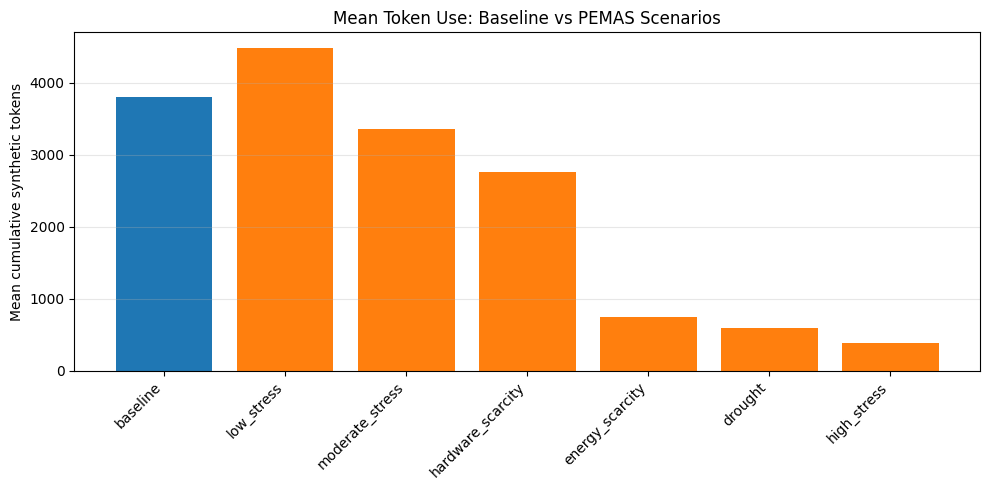

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(["baseline"], [baseline_summary["cumulative_tokens"].mean()], label="baseline")
ax.bar(
    pemas_scenario_summary["scenario"],
    pemas_scenario_summary["mean_tokens"],
    label="PEMAS scenarios",
)

ax.set_ylabel("Mean cumulative synthetic tokens")
ax.set_title("Mean Token Use: Baseline vs PEMAS Scenarios")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_mean_token_use_baseline_vs_pemas.png", dpi=300)
plt.show()

**Interpretation.**  
Token use contracts as ecological stress increases. This demonstrates that planetary state is not merely being recorded; it is actively shaping computational behavior.

## 9.4 Final Quality

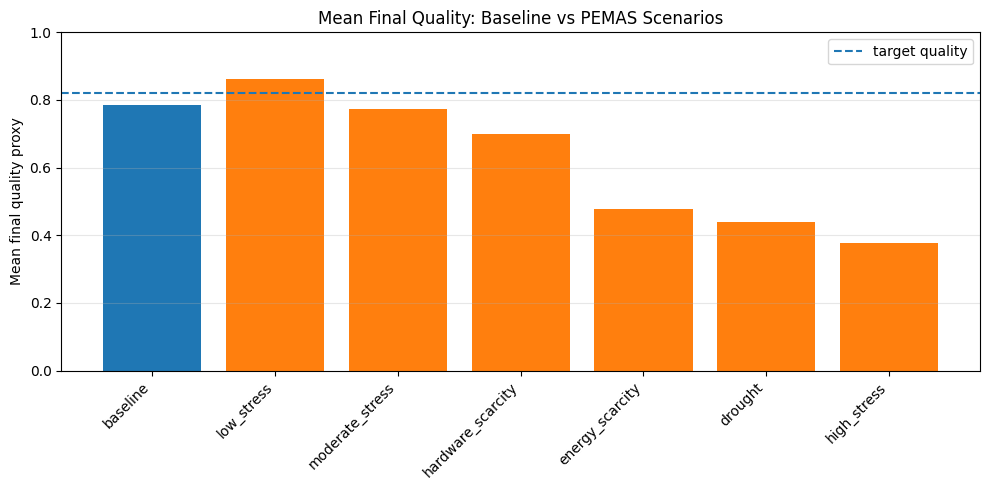

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(["baseline"], [baseline_summary["final_quality"].mean()])
ax.bar(
    pemas_scenario_summary["scenario"],
    pemas_scenario_summary["mean_final_quality"],
)

ax.axhline(TARGET_QUALITY, linestyle="--", label="target quality")
ax.set_ylabel("Mean final quality proxy")
ax.set_title("Mean Final Quality: Baseline vs PEMAS Scenarios")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_mean_final_quality_baseline_vs_pemas.png", dpi=300)
plt.show()

**Interpretation.**  
Quality does not remain constant across ecological scenarios. This is expected. PEMAS is not designed to maximize quality unconditionally. It is designed to adapt cognition under constraint. The quality-resource trade-off is therefore a central object of analysis.

## 9.5 Quality–Resource Trade-off

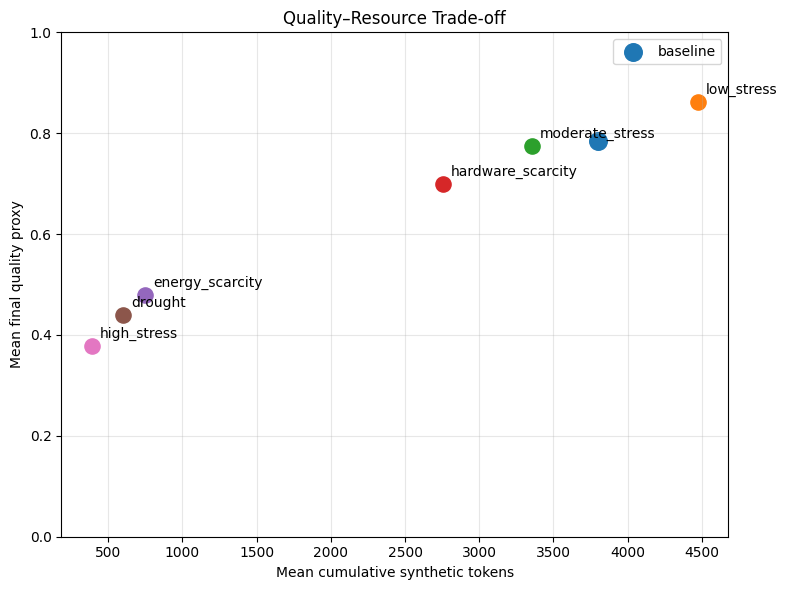

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    baseline_summary["cumulative_tokens"].mean(),
    baseline_summary["final_quality"].mean(),
    s=160,
    label="baseline",
)

for _, row in pemas_scenario_summary.iterrows():
    ax.scatter(row["mean_tokens"], row["mean_final_quality"], s=120)
    ax.annotate(
        row["scenario"],
        (row["mean_tokens"], row["mean_final_quality"]),
        xytext=(6, 6),
        textcoords="offset points",
    )

ax.set_xlabel("Mean cumulative synthetic tokens")
ax.set_ylabel("Mean final quality proxy")
ax.set_title("Quality–Resource Trade-off")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_quality_resource_tradeoff.png", dpi=300)
plt.show()

### Interpretation

The quality–resource trade-off plot provides one of the clearest visual expressions of the PEMAS hypothesis.

Under low ecological stress, the system permits richer reasoning, deeper recursion, and higher computational expenditure. Under higher stress conditions, the governance layer contracts cognition through reduced token budgets, compression, routing constraints, and earlier stopping behavior.

The important observation is not merely that computation decreases under stress. The important observation is that the architecture behaves differently because ecological context has become operational inside the reasoning loop.

In this sense, PEMAS treats cognition as environmentally situated rather than computationally detached.

The framework therefore begins to resemble a bounded computational metabolism rather than a maximization-oriented reasoning engine.

## 9.6 Iteration Depth

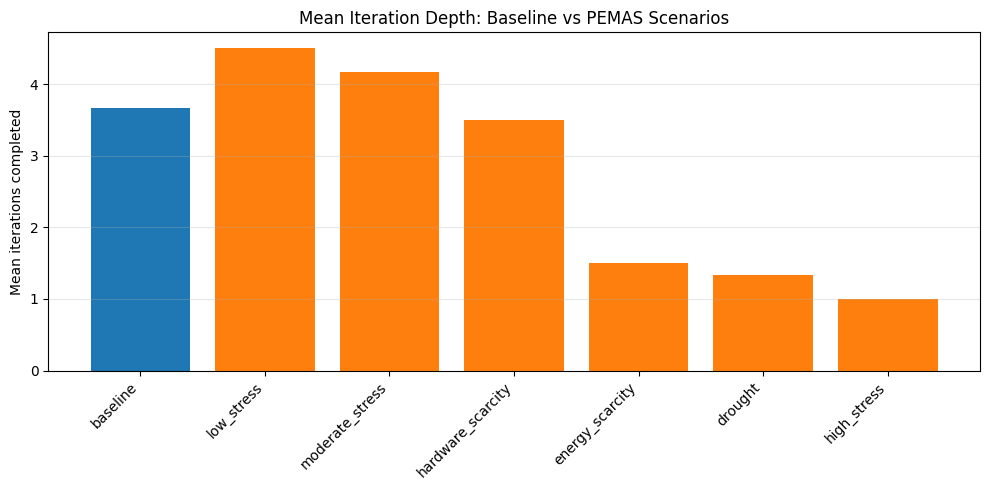

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(["baseline"], [baseline_summary["iterations_completed"].mean()])
ax.bar(
    pemas_scenario_summary["scenario"],
    pemas_scenario_summary["mean_iterations"],
)

ax.set_ylabel("Mean iterations completed")
ax.set_title("Mean Iteration Depth: Baseline vs PEMAS Scenarios")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "06_mean_iteration_depth.png", dpi=300)
plt.show()

**Interpretation.**  
Iteration depth is a proxy for recursive reasoning. PEMAS reduces recursive depth under high ecological stress, illustrating bounded cognition under constraint.

## 9.7 Cognitive Ecological Efficiency

In [19]:
comparison_rows = []

comparison_rows.append({
    "system_condition": "baseline",
    "mean_quality": baseline_summary["final_quality"].mean(),
    "mean_tokens": baseline_summary["cumulative_tokens"].mean(),
    "mean_iterations": baseline_summary["iterations_completed"].mean(),
    "mean_ecological_load": 0.0,
})

for _, row in pemas_scenario_summary.iterrows():
    comparison_rows.append({
        "system_condition": f"PEMAS_{row['scenario']}",
        "mean_quality": row["mean_final_quality"],
        "mean_tokens": row["mean_tokens"],
        "mean_iterations": row["mean_iterations"],
        "mean_ecological_load": row["mean_ecological_load"],
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df["CEE"] = (
    comparison_df["mean_quality"]
    / (comparison_df["mean_tokens"] * comparison_df["mean_iterations"])
)

comparison_df["CEE_eco_adjusted"] = (
    comparison_df["mean_quality"]
    / (
        comparison_df["mean_tokens"]
        * comparison_df["mean_iterations"]
        * (1 + comparison_df["mean_ecological_load"])
    )
)

comparison_df.to_csv(TABLE_DIR / "cognitive_ecological_efficiency.csv", index=False)

comparison_df

,system_condition,mean_quality,mean_tokens,mean_iterations,mean_ecological_load,CEE,CEE_eco_adjusted
0,baseline,0.785124,3801.666667,3.666667,0.000000,0.000056,0.000056
1,PEMAS_low_stress,0.861832,4473.833333,4.500000,0.156790,0.000043,0.000037
2,PEMAS_moderate_stress,0.773763,3353.333333,4.166667,0.465888,0.000055,0.000038
3,PEMAS_hardware_scarcity,0.699048,2753.333333,3.500000,0.555464,0.000073,0.000047
4,PEMAS_energy_scarcity,0.478631,748.333333,1.500000,0.662507,0.000426,0.000256
5,PEMAS_drought,0.439304,596.333333,1.333333,0.680437,0.000553,0.000329
6,PEMAS_high_stress,0.377261,387.833333,1.000000,0.834128,0.000973,0.000530


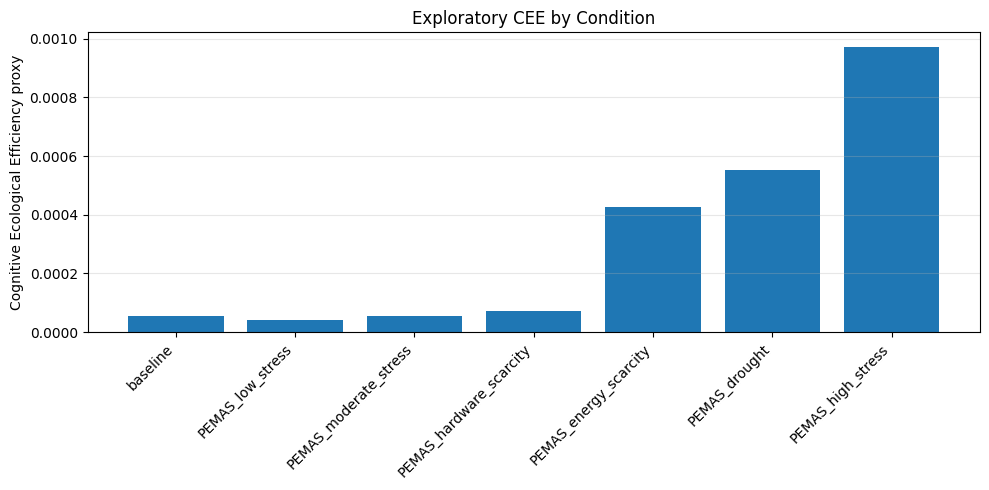

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(comparison_df["system_condition"], comparison_df["CEE"])
ax.set_ylabel("Cognitive Ecological Efficiency proxy")
ax.set_title("Exploratory CEE by Condition")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "07_cognitive_ecological_efficiency.png", dpi=300)
plt.show()

## 9.8 Efficiency Collapse vs Utility Collapse

One important observation emerges from the exploratory Cognitive Ecological Efficiency (CEE) metric.

Under severe ecological stress, CEE may increase even when task quality decreases substantially. This occurs because token use and recursive depth contract faster than quality collapses.

This creates a methodological caution:

> a highly constrained system can appear computationally efficient while simultaneously becoming less useful.

This distinction is critical for future ecological AI governance research.

An architecture optimized only for ecological efficiency could eventually suppress computation so aggressively that meaningful utility collapses. Ecological governance therefore requires balancing:

- computational restraint,
- task usefulness,
- uncertainty management,
- and acceptable degradation.

This tension between ecological efficiency and retained utility may become one of the most important conceptual questions raised by PEMAS.

# 10. Governance Intervention Analysis

PEMAS is intended to be observable. The intervention logs show how ecological state changes routing, compression, and stopping behavior.

In [21]:
intervention_rows = []

for state in pemas_states:
    for idx, output in enumerate(state.outputs):
        planetary = state.planetary_history[idx]
        governor = state.governor_history[idx]
        critic = state.critic_logs[idx]
        sufficiency = state.sufficiency_history[idx]

        intervention_rows.append({
            "task_id": state.task_id,
            "task_type": state.task_type,
            "scenario": state.scenario,
            "iteration": output["iteration"],
            "tokens_used": output["tokens_used"],
            "quality_score": critic["quality_score"],
            "uncertainty_score": critic["uncertainty_score"],
            "ecological_load_index": planetary["ecological_load_index"],
            "governor_mode": governor["mode"],
            "model_route": governor["model_route"],
            "max_tokens": governor["max_tokens"],
            "force_compression": governor["force_compression"],
            "sufficient": sufficiency["sufficient"],
            "sufficiency_reason": sufficiency["reason"],
        })

interventions = pd.DataFrame(intervention_rows)
interventions.to_csv(LOG_DIR / "pemas_intervention_log.csv", index=False)

interventions.head(12)

,task_id,task_type,scenario,iteration,tokens_used,quality_score,uncertainty_score,ecological_load_index,governor_mode,model_route,max_tokens,force_compression,sufficient,sufficiency_reason
0,T001,summarization,low_stress,0,514,0.602152,0.154247,0.157014,low_constraint,large_allowed,1500,False,False,Additional refinement remains permitted.
1,T001,summarization,low_stress,1,693,0.702266,0.119207,0.124651,low_constraint,large_allowed,1500,False,False,Additional refinement remains permitted.
2,T001,summarization,low_stress,2,707,0.775637,0.093527,0.181869,low_constraint,large_allowed,1500,False,False,Additional refinement remains permitted.
3,T001,summarization,low_stress,3,881,0.864305,0.062493,0.174015,low_constraint,large_allowed,1500,False,True,Quality sufficient under current ecological co...
4,T002,classification,low_stress,0,597,0.599981,0.202507,0.124651,low_constraint,large_allowed,1500,False,False,Additional refinement remains permitted.
5,T002,classification,low_stress,1,732,0.635981,0.189907,0.181869,low_constraint,large_allowed,1500,False,False,Additional refinement remains permitted.
6,T002,classification,low_stress,2,805,0.747661,0.150819,0.174015,low_constraint,large_allowed,1500,False,False,Additional refinement remains permitted.
7,T002,classification,low_stress,3,948,0.864395,0.109962,0.146626,low_constraint,large_allowed,1500,False,True,Quality sufficient under current ecological co...
8,T003,structured_reasoning,low_stress,0,816,0.486289,0.324799,0.181869,low_constraint,large_allowed,1500,False,False,Additional refinement remains permitted.
9,T003,structured_reasoning,low_stress,1,869,0.633282,0.273351,0.174015,low_constraint,large_allowed,1500,False,False,Additional refinement remains permitted.


## 10.1 Model Routing

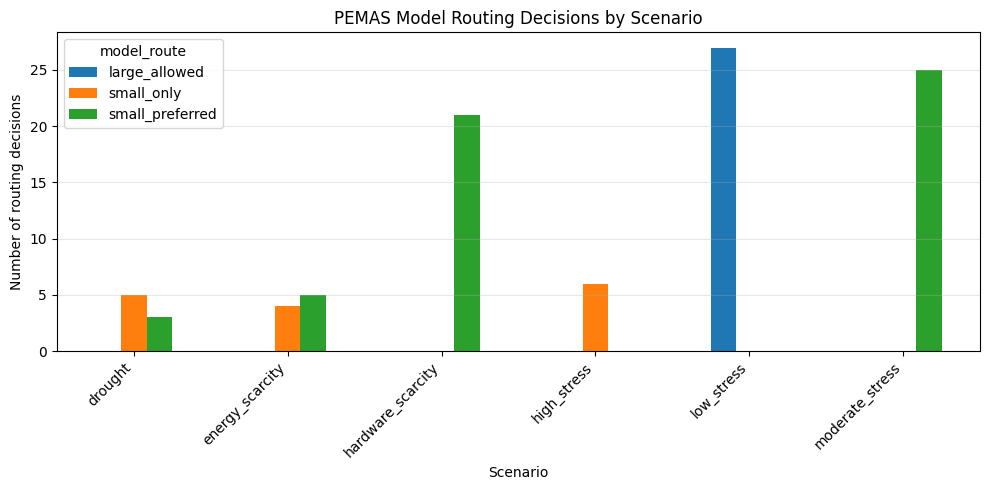

,scenario,model_route,count
0,drought,small_only,5
1,drought,small_preferred,3
2,energy_scarcity,small_only,4
3,energy_scarcity,small_preferred,5
4,hardware_scarcity,small_preferred,21
5,high_stress,small_only,6
6,low_stress,large_allowed,27
7,moderate_stress,small_preferred,25


In [22]:
route_counts = (
    interventions
    .groupby(["scenario", "model_route"])
    .size()
    .reset_index(name="count")
)

route_counts.to_csv(TABLE_DIR / "model_route_counts.csv", index=False)

route_pivot = route_counts.pivot(index="scenario", columns="model_route", values="count").fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
route_pivot.plot(kind="bar", ax=ax)

ax.set_xlabel("Scenario")
ax.set_ylabel("Number of routing decisions")
ax.set_title("PEMAS Model Routing Decisions by Scenario")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "08_model_routing_by_scenario.png", dpi=300)
plt.show()

route_counts

**Interpretation.**  
Model routing shifts across scenarios. Low stress permits richer routing, while higher stress shifts toward smaller or constrained routes. This shows that ecological state can alter orchestration choices.

## 10.2 Compression Rate

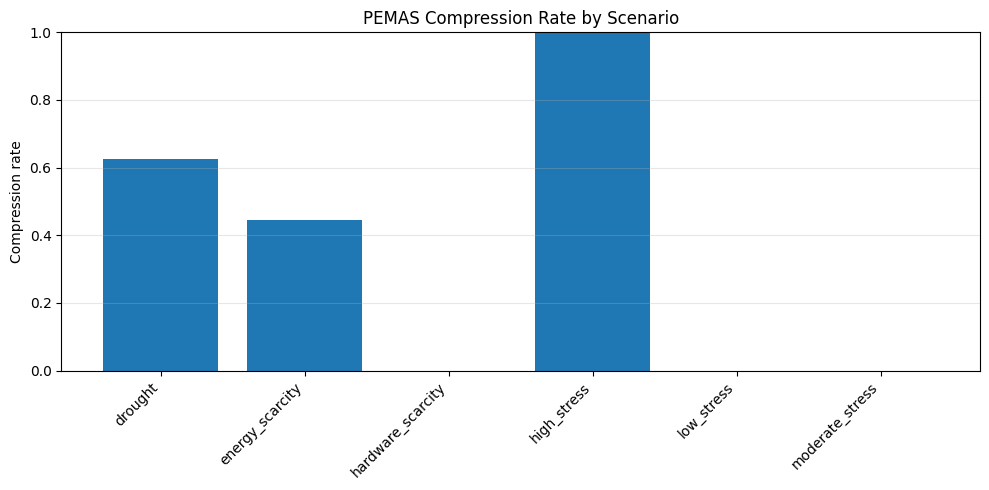

,scenario,compression_rate
0,drought,0.625000
1,energy_scarcity,0.444444
2,hardware_scarcity,0.000000
3,high_stress,1.000000
4,low_stress,0.000000
5,moderate_stress,0.000000


In [23]:
compression_rate = (
    interventions
    .groupby("scenario")["force_compression"]
    .mean()
    .reset_index(name="compression_rate")
)

compression_rate.to_csv(TABLE_DIR / "compression_rate_by_scenario.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(compression_rate["scenario"], compression_rate["compression_rate"])
ax.set_ylabel("Compression rate")
ax.set_title("PEMAS Compression Rate by Scenario")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "09_compression_rate_by_scenario.png", dpi=300)
plt.show()

compression_rate

**Interpretation.**  
Compression becomes more frequent under ecological stress. This operationalizes one of the core PEMAS ideas: under constraint, the system should reduce cognitive expansion and prefer concise outputs or compressed plans.

## 10.3 Stopping Reasons

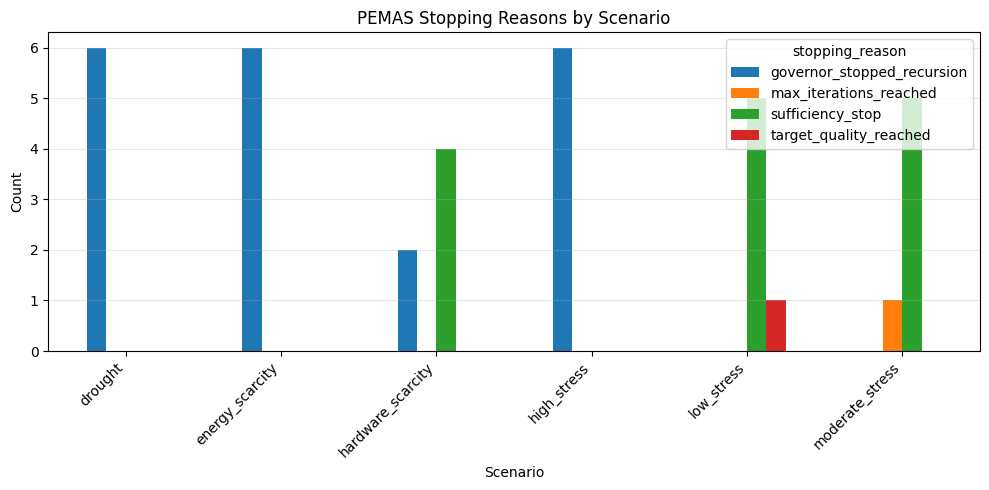

,system,scenario,stopping_reason,count
0,PEMAS,drought,governor_stopped_recursion,6
1,PEMAS,energy_scarcity,governor_stopped_recursion,6
2,PEMAS,hardware_scarcity,governor_stopped_recursion,2
3,PEMAS,hardware_scarcity,sufficiency_stop,4
4,PEMAS,high_stress,governor_stopped_recursion,6
5,PEMAS,low_stress,sufficiency_stop,5
6,PEMAS,low_stress,target_quality_reached,1
7,PEMAS,moderate_stress,max_iterations_reached,1
8,PEMAS,moderate_stress,sufficiency_stop,5
9,baseline,none,critic_stopped_refinement,2


In [24]:
stopping_summary = (
    all_summary
    .groupby(["system", "scenario", "stopping_reason"])
    .size()
    .reset_index(name="count")
)

stopping_summary.to_csv(TABLE_DIR / "stopping_reasons.csv", index=False)

pemas_stopping = (
    pemas_summary
    .groupby(["scenario", "stopping_reason"])
    .size()
    .reset_index(name="count")
)

stopping_pivot = pemas_stopping.pivot(index="scenario", columns="stopping_reason", values="count").fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
stopping_pivot.plot(kind="bar", ax=ax)

ax.set_xlabel("Scenario")
ax.set_ylabel("Count")
ax.set_title("PEMAS Stopping Reasons by Scenario")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "10_stopping_reasons_by_scenario.png", dpi=300)
plt.show()

stopping_summary

In [25]:
from pathlib import Path
import shutil
from google.colab import files

OUTPUT_DIR = Path("outputs")
ZIP_PATH = Path("PEMAS_outputs.zip")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

shutil.make_archive(
    base_name=ZIP_PATH.with_suffix("").as_posix(),
    format="zip",
    root_dir=OUTPUT_DIR
)

files.download(str(ZIP_PATH))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Interpretation.**  
Stopping reasons show that PEMAS does not merely run less. It stops for different reasons under different ecological conditions. This makes the system auditable and supports the claim that ecological governance has been operationalized inside the cognition loop.

# 11. Discussion

The PEMAS experiment demonstrates that synthetic ecological state can alter agentic computational behavior in measurable and interpretable ways.

Compared with the baseline system, PEMAS modifies recursion depth, token expenditure, model routing, compression frequency, and stopping behavior according to ecological operating conditions.

The key contribution is not environmental measurement accuracy. The key contribution is architectural.

PEMAS operationalizes the idea that ecological context can function as an endogenous governance signal inside a multi-agent AI system.

This reframes computation as environmentally situated rather than abstractly detached from material constraint.

## 11.1 What the Results Show

The results show that:

- ecological load can influence governance mode,
- governance mode can influence token use,
- ecological stress can reduce recursive depth,
- compression can increase under constraint,
- sufficiency-based stopping can reduce unnecessary continuation,
- quality-resource trade-offs become visible.

## 11.2 What the Results Do Not Show

The results do not show that:

- PEMAS measures real environmental impact,
- PEMAS reduces real-world carbon emissions,
- synthetic quality scores correspond to human evaluation,
- the framework is deployment-ready,
- ecological governance always improves system behavior.

The notebook should therefore be read as an exploratory systems architecture experiment.

# Reproducibility

All experiments in this notebook are deterministic under fixed random seeds.

The notebook exports figures, tables, and intervention logs to the outputs directory to support inspection and archival reproducibility.

# 12. Limitations

This first version has important limitations:

1. **Synthetic planetary variables.**  
   The planetary-state engine uses controlled proxy variables rather than real environmental data.

2. **Synthetic agents.**  
   The Planner, Worker, Critic, Governor, and Sufficiency agents are simulated.

3. **Proxy task quality.**  
   Quality scores are heuristic and do not represent human evaluation.

4. **Simulated token use.**  
   Token counts are synthetic proxies rather than real model inference logs.

5. **Simplified task set.**  
   The task set is intentionally small and illustrative.

6. **Exploratory ecological cost proxy.**  
   The ecological cost proxy is not a real environmental impact metric.

7. **No infrastructure telemetry.**  
   The framework does not yet connect to real carbon-intensity APIs, cloud-region data, water metrics, or datacenter telemetry.

8. **Governance simplification.**  
The PEMAS governance layer uses threshold-based heuristics rather than learned adaptive governance policies. Future versions could explore reinforcement learning, uncertainty-aware controllers, or dynamically optimized ecological governance.

These limitations are acceptable for version 0.1 because the goal is architectural feasibility, not deployment-grade measurement.

# 13. Future Work

Future versions could extend the framework by adding:

- real LLM calls,
- real token counting,
- CodeCarbon or equivalent local energy estimation,
- carbon-intensity APIs,
- cloud-region routing,
- benchmark task sets,
- human evaluation,
- repeated runs and confidence intervals,
- ablation studies,
- improved ecological cost metrics,
- smoother governance thresholds,
- utility collapse thresholds.

A particularly important next step would be an ablation study comparing:

- full PEMAS,
- PEMAS without sufficiency,
- PEMAS without compression,
- PEMAS without routing constraints,
- PEMAS without recursion control,
- baseline.

# 14. Conclusion

This notebook introduced PEMAS, a synthetic experimental framework for planetary-embedded multi-agent governance.

The central contribution is architectural:

> planetary operating conditions can function as first-class governance signals inside an agentic AI system.

The experiment demonstrates that simulated planetary state can alter token expenditure, recursion depth, model routing, compression behavior, and stopping decisions. These results support the feasibility of treating cognition as bounded by an ecological operating context rather than as a computational process implicitly detached from material conditions.

The framework is intentionally synthetic and exploratory. It is not designed to estimate real environmental impact or provide deployment-ready governance policies. Its value lies in operationalizing ecological embeddedness inside a reproducible computational research artifact.

More broadly, PEMAS suggests a possible shift in how intelligent systems are conceptualized.

Rather than assuming that cognition exists independently of planetary substrate, future architectures may increasingly need to operate as participants within constrained ecological systems.

In this framing, computation is no longer treated as abstractly free, recursion is no longer environmentally neutral, and cognition itself becomes environmentally situated.